# Dataset and Preprocessing Overview

This notebook documents the three datasets used in the NLP Practical Project
and demonstrates the text preprocessing pipeline applied to each.

**Datasets covered:**
- IMDB Movie Reviews (English, binary sentiment)
- Romanian Categorized Web Articles (Romanian, 3-class sentiment)
- REDv2 Romanian Emotion Dataset (Romanian, multi-label, 7 emotion classes)

**How to use:** Run all cells top-to-bottom. No training scripts need to be run first.

**Environment:** `nlp-practical` conda env · Apple M4 Pro · Python 3.11

## 1 · Setup and Imports

In [1]:
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Set working directory to Practical_Project/ so all local module imports
# and dataset path resolution work correctly from the notebooks/ subfolder.
PROJECT_DIR = Path("..").resolve()
os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR))
sys.path.insert(0, str(PROJECT_DIR / "shared" / "migrated"))
sys.path.insert(0, str(PROJECT_DIR / "2_Romanian" / "shared"))
sys.path.insert(0, str(PROJECT_DIR / "1_English" / "shared"))

from preprocessing_en import preprocess as preprocess_imdb
from preprocessing_ro import preprocess as preprocess_ro
from preprocessing_red import preprocess as preprocess_red

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

print("Setup complete. Working directory:", Path.cwd())

Setup complete. Working directory: /Users/bogdanpurdea/Projects/Applied-Computational-Intelligence-UBB/Year1_Semester2_NaturalLanguageProcessing_NLP/NLP_Project


## 2 · IMDB Movie Reviews Dataset

The IMDB 50k dataset contains 25,000 positive and 25,000 negative movie
reviews. It is split 70 / 15 / 15 (train / val / test) using stratified
sampling to preserve class balance.

- **Task:** Binary sentiment classification (positive / negative)
- **Language:** English
- **Size:** 50,000 reviews
- **Source:** https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

In [2]:
imdb_path = Path("Datasets/migrated/imdb_movie_reviews/imdb.csv")
assert imdb_path.exists(), (
    f"IMDB CSV not found at {imdb_path}. Run: python dataset.py"
)
df_imdb = pd.read_csv(imdb_path)
print(f"Total rows : {len(df_imdb):,}")
print(f"Columns    : {list(df_imdb.columns)}")
df_imdb.head(3)

Total rows : 50,000
Columns    : ['review', 'sentiment', 'label']


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1


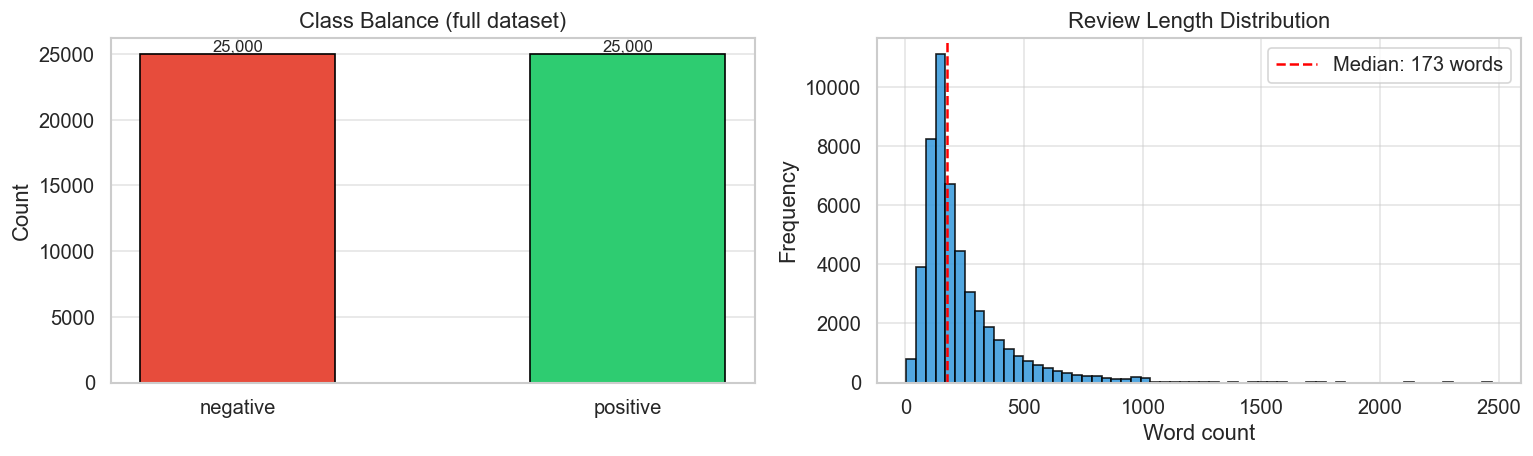

Median review length : 173 words
Max review length    : 2,470 words


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart: class balance
counts = df_imdb["label"].value_counts().rename({0: "negative", 1: "positive"})
axes[0].bar(counts.index, counts.values, color=["#e74c3c", "#2ecc71"],
            edgecolor="black", width=0.5)
axes[0].set_title("Class Balance (full dataset)")
axes[0].set_ylabel("Count")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["negative", "positive"])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontsize=10)

# Histogram: review length in words
word_counts = df_imdb["review"].str.split().apply(len)
axes[1].hist(word_counts, bins=60, color="#3498db", edgecolor="black", alpha=0.85)
axes[1].axvline(word_counts.median(), color="red", linestyle="--",
                label=f"Median: {word_counts.median():.0f} words")
axes[1].set_title("Review Length Distribution")
axes[1].set_xlabel("Word count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Median review length : {word_counts.median():.0f} words")
print(f"Max review length    : {word_counts.max():,} words")

## 3 · IMDB Preprocessing Pipeline

The pipeline (`preprocessing.py`) applies the following steps **in order**:

| Step | Why |
|---|---|
| Remove HTML tags | IMDB reviews contain `<br />` etc. |
| Remove URLs / mentions | Noise with no sentiment value |
| Normalize ASCII emoticons | `:)` → `happy` (preserves sentiment) |
| Convert unicode emojis | 😊 → `smiling face` |
| Expand contractions | `don't` → `do not` (critical for negation) |
| Cap repeated chars | `sooooo` → `sooo` |
| Normalize whitespace | Clean up multi-spaces |

> **Design choice**: Punctuation (`!`, `?`, `.`) and stop words are
> **intentionally preserved** — they carry sentiment signal for transformers.

In [4]:
samples_imdb = [
    "I loved it sooooo much!!! :D Great film <br/>check it out at http://imdb.com",
    "Don't watch this... it's the worst movie I've ever seen :( ugh 😤",
    "Meh. Not bad, not great :/  <br /><br />just... okay I guess.",
]

print("=" * 70)
for i, raw in enumerate(samples_imdb):
    cleaned = preprocess_imdb(raw)
    print(f"[{i+1}] RAW   : {raw}")
    print(f"    CLEAN : {cleaned}")
    print()

[1] RAW   : I loved it sooooo much!!! :D Great film <br/>check it out at http://imdb.com
    CLEAN : I loved it sooo much!!! very happy Great film check it out at

[2] RAW   : Don't watch this... it's the worst movie I've ever seen :( ugh 😤
    CLEAN : Do not watch this... it is the worst movie I have ever seen sad ugh face with steam from nose

[3] RAW   : Meh. Not bad, not great :/  <br /><br />just... okay I guess.
    CLEAN : Meh. Not bad, not great unsure just... okay I guess.



## 4 · Romanian Categorized Web Articles Dataset

The Romanian Categorized Web Articles dataset contains news articles
from Romanian web sources labeled with sentiment.

- **Task:** 3-class sentiment classification (positive / negative / neutral)
- **Language:** Romanian
- **Split:** 70 / 15 / 15 (train / val / test), stratified on label
- **File:** `data/ro_article_reviews/ro_articles.csv`

In [5]:
from dataset_ro import load_splits as ro_load_splits

df_train_ro, df_val_ro, df_test_ro = ro_load_splits()
df_ro = pd.concat([df_train_ro, df_val_ro, df_test_ro], ignore_index=True)

print(f"Total rows : {len(df_ro):,}")
print(f"  Train    : {len(df_train_ro):,}")
print(f"  Val      : {len(df_val_ro):,}")
print(f"  Test     : {len(df_test_ro):,}")
print(f"Columns    : {list(df_ro.columns)}")
df_ro.head(3)

[dataset_ro] Splits — train: 2,128  val: 457  test: 457
Total rows : 3,042
  Train    : 2,128
  Val      : 457
  Test     : 457
Columns    : ['article', 'sentiment', 'label']


,article,sentiment,label
0,Neobișnuitele costume de baie purtate pe unele...,neutral,2
1,Întrebare aparent ciudată: Sunt virușii organi...,neutral,2
2,Papuci marocani | DivaHair.ro Am acceptat deja...,positive,1


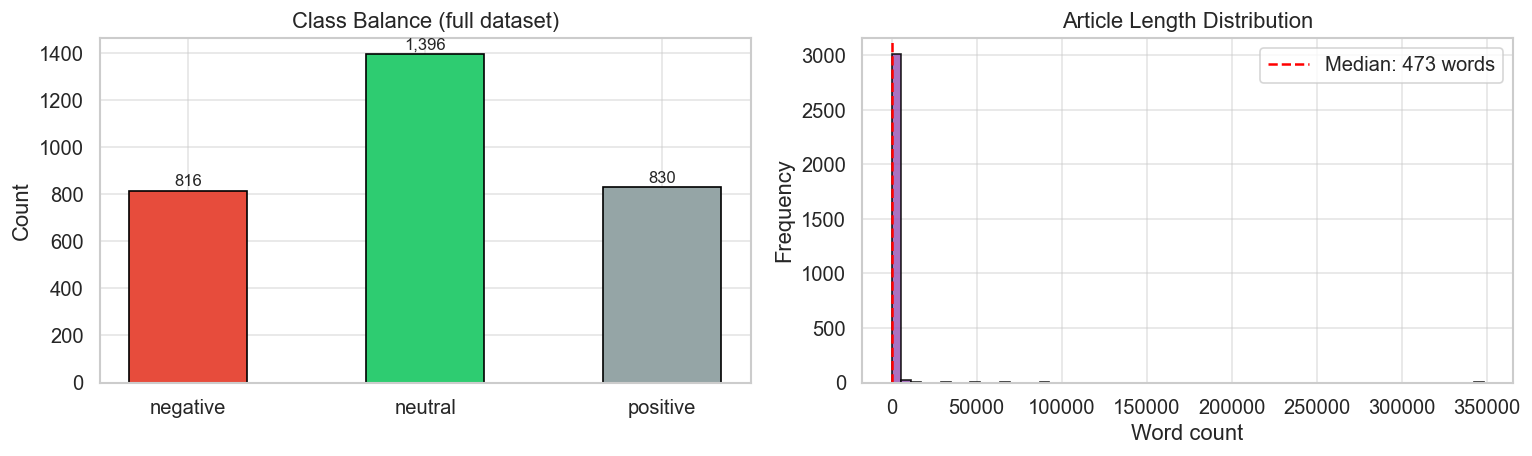

Median article length : 473 words
Max article length    : 348,125 words


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart: class balance
label_map = {0: "negative", 1: "positive", 2: "neutral"}
counts_ro = df_ro["label"].value_counts().rename(label_map).sort_index()
colors_ro = ["#e74c3c", "#2ecc71", "#95a5a6"]
axes[0].bar(counts_ro.index, counts_ro.values, color=colors_ro,
            edgecolor="black", width=0.5)
axes[0].set_title("Class Balance (full dataset)")
axes[0].set_ylabel("Count")
axes[0].set_xticks(list(counts_ro.index))
axes[0].set_xticklabels(list(counts_ro.index))
for i, (idx, v) in enumerate(counts_ro.items()):
    axes[0].text(i, v + 20, f"{v:,}", ha="center", fontsize=10)

# Histogram: article length in words
word_counts_ro = df_ro["article"].str.split().apply(len)
axes[1].hist(word_counts_ro, bins=60, color="#9b59b6", edgecolor="black", alpha=0.85)
axes[1].axvline(word_counts_ro.median(), color="red", linestyle="--",
                label=f"Median: {word_counts_ro.median():.0f} words")
axes[1].set_title("Article Length Distribution")
axes[1].set_xlabel("Word count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Median article length : {word_counts_ro.median():.0f} words")
print(f"Max article length    : {word_counts_ro.max():,} words")

## 5 · Romanian Articles Preprocessing Pipeline

The pipeline (`preprocessing_ro.py`) applies the following steps **in order**:

| Step | Why |
|---|---|
| Remove HTML tags | Web articles may contain HTML markup |
| Remove URLs / mentions | Noise with no sentiment value |
| Normalize ASCII emoticons | `:)` → `fericit` (Romanian for "happy") |
| Convert unicode emojis | 😊 → text descriptions |
| Cap repeated chars | `sooooo` → `sooo` |
| Normalize whitespace | Clean up multi-spaces |

> **Design choices**: No contraction expansion (text is Romanian, not English).
> Romanian diacritics (ș, ț, ă, â, î) are **preserved** — they are part of
> the Romanian BERT vocabulary.

In [7]:
samples_ro = [
    "Am adorat filmul sooooo mult!!! :D Super recomandat <br/>vezi-l la http://cinemagia.ro",
    "Nu merită deloc... cel mai prost film văzut vreodată :( 😤",
    "Decent, nu e nici bun nici rău :/  <br /><br />merge și el.",
]

print("=" * 70)
for i, raw in enumerate(samples_ro):
    cleaned = preprocess_ro(raw)
    print(f"[{i+1}] RAW   : {raw}")
    print(f"    CLEAN : {cleaned}")
    print()

[1] RAW   : Am adorat filmul sooooo mult!!! :D Super recomandat <br/>vezi-l la http://cinemagia.ro
    CLEAN : Am adorat filmul sooo mult!!! foarte fericit Super recomandat vezi-l la

[2] RAW   : Nu merită deloc... cel mai prost film văzut vreodată :( 😤
    CLEAN : Nu merită deloc... cel mai prost film văzut vreodată trist face with steam from nose

[3] RAW   : Decent, nu e nici bun nici rău :/  <br /><br />merge și el.
    CLEAN : Decent, nu e nici bun nici rău nesigur merge și el.



## 6 · REDv2 Romanian Emotion Dataset

The REDv2 dataset contains Romanian social-media texts annotated with
emotion labels by multiple annotators. It uses a **multi-label** scheme
where each text can express one or more of 7 emotions simultaneously.

- **Task:** Multi-label emotion classification
- **Language:** Romanian
- **Emotion classes:** sadness, surprise, fear, anger, neutral, trust, joy
- **Split:** Pre-built `train.csv` / `valid.csv` / `test.csv` in `data/red/`
- **Labels:** `agreed_label_{emotion}` (binary 0/1) — majority-vote across annotators
- **Extra columns:** `pct_label_{emotion}` (annotator agreement ratio),
  `num_emotions`, `is_multilabel`, `has_short_text`

In [8]:
from dataset_red import load_splits as red_load_splits, EMOTION_LABELS, AGREED_LABEL_COLS

df_train_red, df_val_red, df_test_red = red_load_splits(task="classification")
df_red = pd.concat([df_train_red, df_val_red, df_test_red], ignore_index=True)

print(f"Total rows : {len(df_red):,}")
print(f"  Train    : {len(df_train_red):,}")
print(f"  Val      : {len(df_val_red):,}")
print(f"  Test     : {len(df_test_red):,}")
print(f"Emotion labels : {EMOTION_LABELS}")
df_red[["text", *AGREED_LABEL_COLS, "num_emotions", "is_multilabel"]].head(5)

[dataset_red] Splits — train: 4,088  val: 543  test: 818
Total rows : 5,449
  Train    : 4,088
  Val      : 543
  Test     : 818
Emotion labels : ['sadness', 'surprise', 'fear', 'anger', 'neutral', 'trust', 'joy']


,text,agreed_label_sadness,agreed_label_surprise,agreed_label_fear,agreed_label_anger,agreed_label_neutral,agreed_label_trust,agreed_label_joy,num_emotions,is_multilabel
0,"Muie tuturor rețelelor sociale, nu au stors un...",0,0,0,1,0,0,0,1,False
1,<|PERSON|> anunță că Spitalul Victor Babeș din...,1,0,0,0,0,0,0,1,False
2,credeam ca o sa omori pe cineva m-ai speriat n...,0,0,1,0,0,0,0,1,False
3,UPDATE. Atac cu cuțitul în Nisa: trei au murit...,0,0,1,0,1,0,0,2,True
4,În ochii tăi am văzut un talent extraordinar! ...,0,0,0,0,0,1,0,1,False


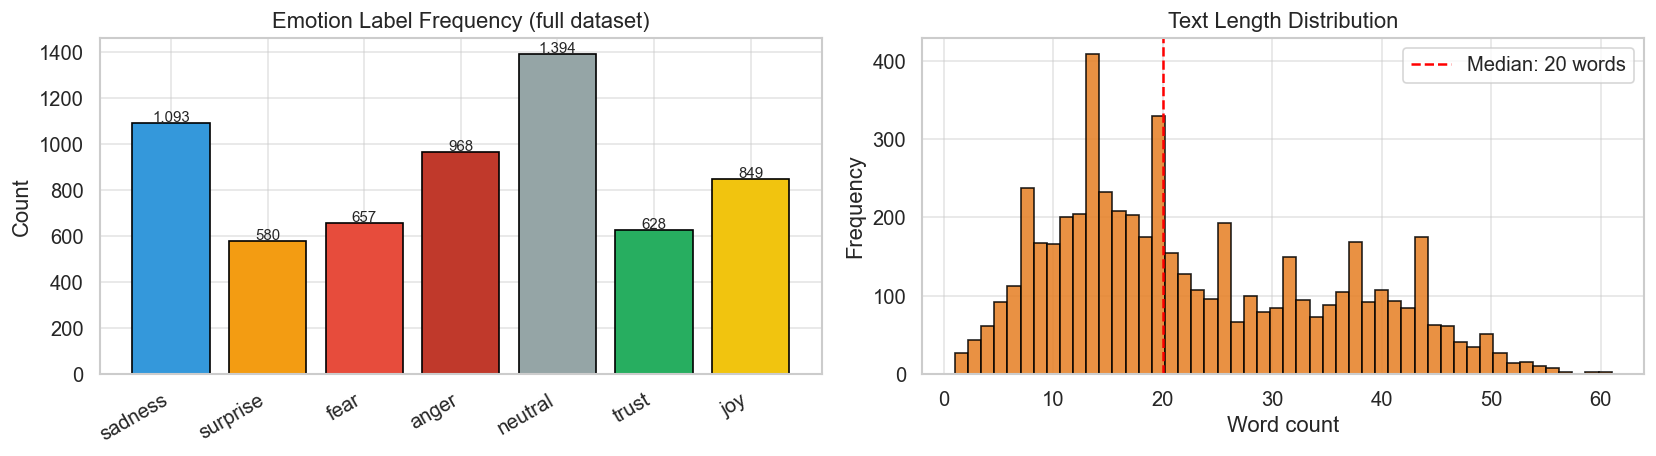

Median text length : 20 words
Max text length    : 61 words


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart: per-emotion label frequency
emotion_counts = df_red[AGREED_LABEL_COLS].sum().rename(
    {f"agreed_label_{e}": e for e in EMOTION_LABELS}
)
palette = ["#3498db", "#f39c12", "#e74c3c", "#c0392b", "#95a5a6", "#27ae60", "#f1c40f"]
axes[0].bar(emotion_counts.index, emotion_counts.values, color=palette, edgecolor="black")
axes[0].set_title("Emotion Label Frequency (full dataset)")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(emotion_counts.index, rotation=30, ha="right")
for i, v in enumerate(emotion_counts.values):
    axes[0].text(i, v + 5, f"{int(v):,}", ha="center", fontsize=9)

# Histogram: text length in words
word_counts_red = df_red["text"].str.split().apply(len)
axes[1].hist(word_counts_red, bins=50, color="#e67e22", edgecolor="black", alpha=0.85)
axes[1].axvline(word_counts_red.median(), color="red", linestyle="--",
                label=f"Median: {word_counts_red.median():.0f} words")
axes[1].set_title("Text Length Distribution")
axes[1].set_xlabel("Word count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Median text length : {word_counts_red.median():.0f} words")
print(f"Max text length    : {word_counts_red.max():,} words")

In [10]:
# Multi-label statistics
n_total = len(df_red)
n_multilabel = df_red["is_multilabel"].sum()
mean_emotions = df_red["num_emotions"].mean()

print(f"Total samples        : {n_total:,}")
print(f"Multi-label samples  : {n_multilabel:,} ({100*n_multilabel/n_total:.1f}%)")
print(f"Single-label samples : {n_total - n_multilabel:,} ({100*(n_total-n_multilabel)/n_total:.1f}%)")
print(f"Mean emotions/sample : {mean_emotions:.2f}")
print()
print("Emotions per sample distribution:")
print(df_red["num_emotions"].value_counts().sort_index().to_string())

Total samples        : 5,449
Multi-label samples  : 695 (12.8%)
Single-label samples : 4,754 (87.2%)
Mean emotions/sample : 1.13

Emotions per sample distribution:
num_emotions
1    4754
2     671
3      23
4       1


## 7 · REDv2 Preprocessing Pipeline

The pipeline (`preprocessing_red.py`) applies the following steps **in order**:

| Step | Why |
|---|---|
| Remove HTML tags | Social-media text may contain markup |
| Remove URLs / mentions | Noise with no emotion signal |
| Normalize ASCII emoticons | `:)` → `fericit` (Romanian for "happy") |
| Convert unicode emojis | 😊 → text descriptions |
| Cap repeated chars | `sooooo` → `sooo` |
| Normalize whitespace | Clean up multi-spaces |
| Deduplication (batch) | Exact-match dedup on cleaned text — keeps first occurrence |

> **Design choices**: Identical steps to the Romanian Articles pipeline.
> No contraction expansion (Romanian). Diacritics preserved.
> Deduplication is a **batch-level** step that also returns kept indices
> so label arrays can be kept in sync.

In [11]:
samples_red = [
    ":D sooooo fericiți că am câștigat! 🎉",
    "Nu suport situația asta :( mă enervează nespus 😤 @toatălumea",
    "Meh... nici bine nici rău :/ <br/>o zi normală.",
]

print("=" * 70)
for i, raw in enumerate(samples_red):
    cleaned = preprocess_red(raw)
    print(f"[{i+1}] RAW   : {raw}")
    print(f"    CLEAN : {cleaned}")
    print()

[1] RAW   : :D sooooo fericiți că am câștigat! 🎉
    CLEAN : foarte fericit sooo fericiți că am câștigat! party popper

[2] RAW   : Nu suport situația asta :( mă enervează nespus 😤 @toatălumea
    CLEAN : Nu suport situația asta trist mă enervează nespus face with steam from nose

[3] RAW   : Meh... nici bine nici rău :/ <br/>o zi normală.
    CLEAN : Meh... nici bine nici rău nesigur o zi normală.

